In [161]:
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from nltk.tokenize.treebank import TreebankWordDetokenizer
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import gensim
from gensim.utils import simple_preprocess
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import spacy
import pickle
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import tensorflow as tf
import keras

In [162]:
train = pd.read_csv("train.csv")
train.head(10)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
5,28b57f3990,http://www.dothebouncy.com/smf - some shameles...,http://www.dothebouncy.com/smf - some shameles...,neutral
6,6e0c6d75b1,2am feedings for the baby are fun when he is a...,fun,positive
7,50e14c0bb8,Soooo high,Soooo high,neutral
8,e050245fbd,Both of you,Both of you,neutral
9,fc2cbefa9d,Journey!? Wow... u just became cooler. hehe....,Wow... u just became cooler.,positive


In [163]:
train.groupby("sentiment").nunique()

,textID,text,selected_text
sentiment,,,
negative,7781,7781,5861
neutral,11118,11117,11111
positive,8582,8582,5537


In [164]:
train = train[["selected_text","sentiment"]]
train.head(10)

,selected_text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD,negative
2,bullying me,negative
3,leave me alone,negative
4,"Sons of ****,",negative
5,http://www.dothebouncy.com/smf - some shameles...,neutral
6,fun,positive
7,Soooo high,neutral
8,Both of you,neutral
9,Wow... u just became cooler.,positive


In [165]:
train["selected_text"] = train["selected_text"].fillna("No content")

In [166]:
# Data cleaning
def depure_data(data):
    # Remove URLs with a regular expression
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    data = url_pattern.sub(r'', data)

    # Remove emails
    data = re.sub('\S*@\S*\s?', '', data)

    # Remove new line characters
    data = re.sub('\s+', ' ', data)

    # Remove distracting single quotes
    data = re.sub("\'", "", data)
        
    return data

# Remove repeating words from dataset
def sentences_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence),     deacc=True))

# Normalize text, lowercase
def clean_text(text):
    text = depure_data(str(text))
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

train["best_text"] = train["selected_text"].fillna("No content").apply(clean_text)
train["best_text"].head(10)

0                  i`d have responded, if i were going
1                                             sooo sad
2                                          bullying me
3                                       leave me alone
4                                        sons of ****,
5    - some shameless plugging for the best rangers...
6                                                  fun
7                                           soooo high
8                                          both of you
9                         wow... u just became cooler.
Name: best_text, dtype: str

In [167]:
# Label encoding - convert sentiment labels to integers for model to use
y = train["sentiment"].map({"neutral": 0, "negative": 1, "positive": 2}).to_numpy()
labels = tf.keras.utils.to_categorical(y, 3)

In [168]:
# Transform text data into padded sequences for model
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 8000
max_len = 40

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(train["best_text"])
sequences = tokenizer.texts_to_sequences(train["best_text"])
texts = pad_sequences(sequences, maxlen=max_len)

In [169]:
best_texts = train["best_text"].values
# Split data into train and test data for model
X_train, X_test, y_train, y_test, X_train_texts, X_test_texts = train_test_split(texts, labels, best_texts, test_size=0.2, random_state=42, stratify=y)

# Build Bidirectional GRU Neural Network
model = keras.Sequential()
model.add(layers.Embedding(max_words, 128, input_length=max_len))
model.add(layers.Bidirectional(layers.GRU(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)))
model.add(layers.GlobalMaxPool1D())
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dropout(0.4))
model.add(layers.Dense(3, activation="softmax"))
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)

In [170]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs=12, batch_size=128, callbacks=[early_stop], verbose=1)

print()
# Print sample predictions for first 10 test examples
print("Sample predictions:")
label_map = {0: "neutral", 1: "negative", 2: "positive"}
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions[:10], axis=1)
true_classes = np.argmax(y_test[:10], axis=1)
for i, (predicted, true, confidence, text) in enumerate(zip(predicted_classes, true_classes, predictions[:10], X_test_texts[:10]), start=1):
    print(f'\nSample {i}: "{text}"')
    print(f"True: {label_map[true]}, Predicted: {label_map[predicted]}, Confidence: {confidence[predicted]:.4f}")

print()
print("Test data:")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print("Model accuracy: ", test_acc)
print("Best validation accuracy:", max(history.history["val_accuracy"]))

Epoch 1/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6978 - loss: 0.7129 - val_accuracy: 0.8104 - val_loss: 0.4767
Epoch 2/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8546 - loss: 0.4014 - val_accuracy: 0.8258 - val_loss: 0.4478
Epoch 3/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8931 - loss: 0.3125 - val_accuracy: 0.8272 - val_loss: 0.4793
Epoch 4/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9087 - loss: 0.2649 - val_accuracy: 0.8199 - val_loss: 0.5035
Epoch 5/12
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9229 - loss: 0.2312 - val_accuracy: 0.8190 - val_loss: 0.5468

Sample predictions:
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Sample 1: "heart breaking"
True: negative, Predicted: negative, Confidence: 0.7988

Sample 2: "ughhhhhhhh i don`t feel good"
True: negative, Predicted: negative, Confidence: 0.6745

Sample 3: "have spent half of the day troubleshooting something that wasn`t even within my control. clusters d

<Axes: >

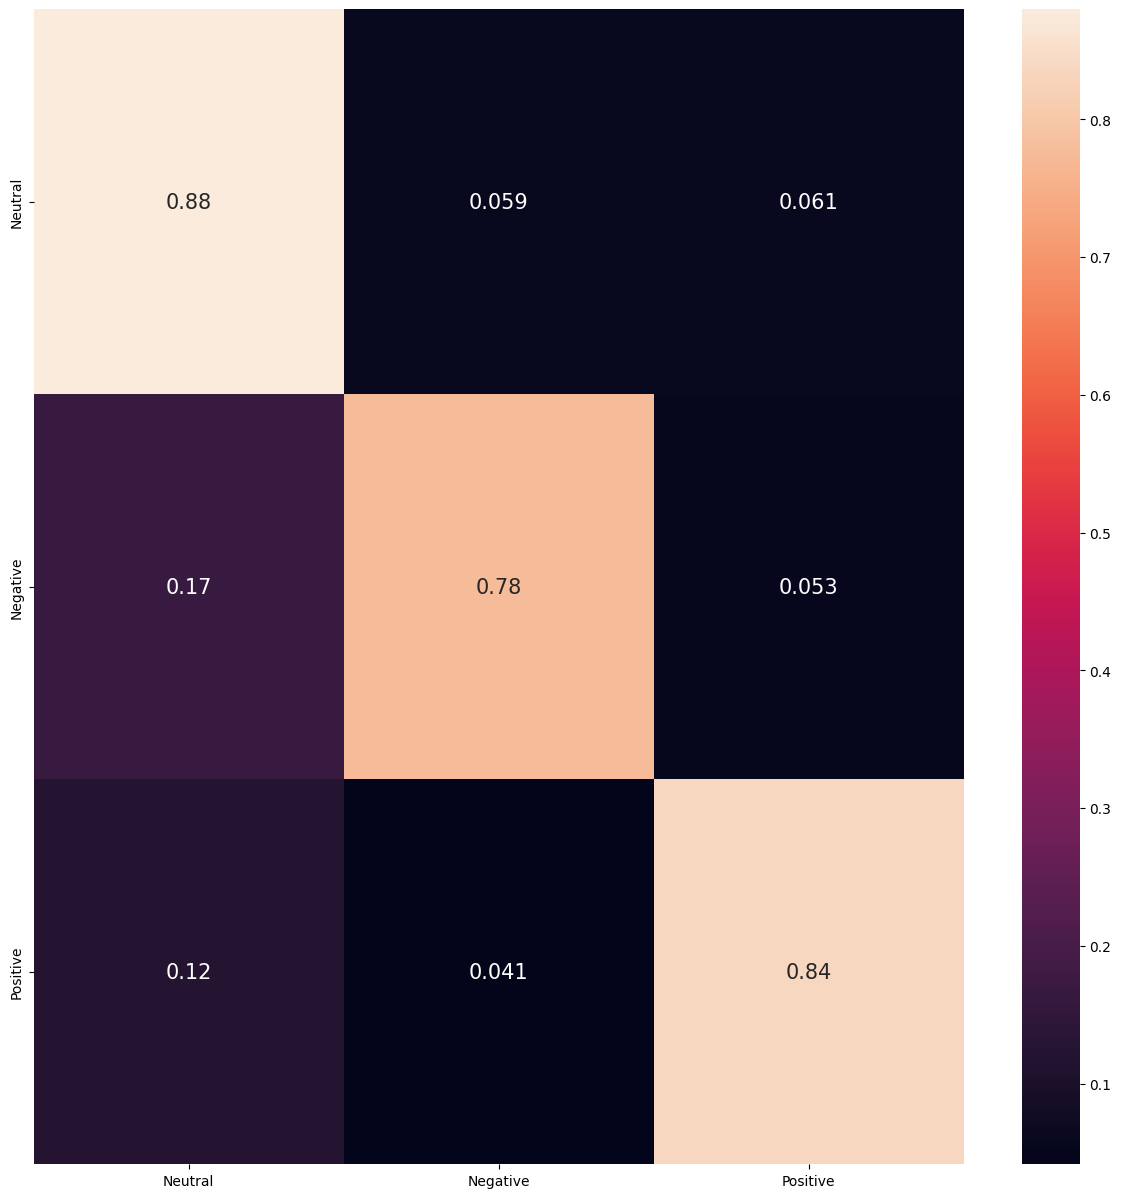

In [180]:
# Plot confusion matrix for model
matrix = confusion_matrix(y_test.argmax(axis=1), np.argmax(predictions, axis=1))
conf_matrix = pd.DataFrame(matrix, index=["Neutral", "Negative", "Positive"], columns=["Neutral", "Negative", "Positive"])
# Normalizing
conf_matrix = conf_matrix.astype("float") / conf_matrix.sum(axis=1).to_numpy()[:, np.newaxis]
plt.figure(figsize=(15,15))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size": 15})